In [2]:
from monai.networks.nets import UNet
from monai.networks.layers import Norm
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

2026-01-03 10:56:01.192278: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-03 10:56:02.634587: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


cuda


In [3]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    norm=Norm.BATCH
).to(device)

print(model)

model.load_state_dict(torch.load("best_metric_model.pth"))

UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): BatchNorm3d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Sequential(


<All keys matched successfully>

In [4]:
import glob
from pathlib import Path
from monai.data import Dataset, DataLoader
from monai.data.image_reader import NibabelReader
from sklearn.model_selection import train_test_split

try:
    import nibabel  # ensure dependency available
except ImportError as exc:
    raise ImportError("nibabel is required for loading NIfTI files. Install via `pip install nibabel`." ) from exc
import numpy as np

# Initialize NIfTI reader
nibabel_reader = NibabelReader()

# Data directory
data_dir = Path("data/ATLAS_2/Training")

# Find all image and mask pairs
image_files = sorted(glob.glob(str(data_dir / "**/*_T1w.nii.gz"), recursive=True))
mask_files = sorted(glob.glob(str(data_dir / "**/*_label-L_desc-T1lesion_mask.nii.gz"), recursive=True))

print(f"Found {len(image_files)} image files")
print(f"Found {len(mask_files)} mask files")

# Create data dictionary
indistribution_data = [
    {"image": img, "label": mask}
    for img, mask in zip(image_files, mask_files)
]

# Split into train and validation (80/20)
train_data, val_data = train_test_split(indistribution_data, test_size=0.2, random_state=42)
print(f"Train data: {len(train_data)} files")
print(f"Validation data: {len(val_data)} files")

Found 655 image files
Found 655 mask files
Train data: 524 files
Validation data: 131 files


In [5]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Spacingd,
    Orientationd,
    ScaleIntensityRanged,
    CropForegroundd,
    ToTensord,
)
from monai.data import Dataset, DataLoader

transform = Compose([
    LoadImaged(keys=["image", "label"], reader=nibabel_reader, image_only=False),
    EnsureChannelFirstd(keys=["image", "label"]),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    ToTensord(keys=["image", "label"]),
])

train_id_ds = Dataset(data=train_data, transform=transform)
train_id_loader = DataLoader(train_id_ds, batch_size=1, num_workers=4, pin_memory=True)

val_id_ds = Dataset(data=val_data, transform=transform)
val_id_loader = DataLoader(val_id_ds, batch_size=1, num_workers=4, pin_memory=True)

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [6]:
from monai.inferers import sliding_window_inference
from tqdm import tqdm
import pickle

def compute_id_scores(model, id_loader):
    model.eval()
    id_scores = []
    with torch.no_grad():
        for batch_data in tqdm(id_loader, "Computing ID scores"):
            image = batch_data["image"].to(device)
            output = sliding_window_inference(image, (96, 96, 96), 4, model, overlap=0.5)
            confidence_score = torch.sigmoid(output)
            mcs = torch.max(confidence_score, 1 - confidence_score)
            id_scores.append(torch.min(mcs).cpu().item())
    return id_scores

pickle_filename = "id_scores.pkl"
if Path(pickle_filename).exists():
    with open(pickle_filename, "rb") as fp:
        id_scores = pickle.load(fp)
else:
    id_scores = compute_id_scores(model, train_id_loader)
    with open(pickle_filename, "wb") as fp:
        pickle.dump(id_scores, fp)

id_scores


[0.5002049207687378,
 0.5000016689300537,
 0.501123309135437,
 0.500157356262207,
 0.5000414252281189,
 0.5003902316093445,
 0.5000486373901367,
 0.5000016093254089,
 0.500056266784668,
 0.5004526376724243,
 0.500363290309906,
 0.5001386404037476,
 0.5001851916313171,
 0.5001735687255859,
 0.5000277757644653,
 0.5000454783439636,
 0.5000028610229492,
 0.5000772476196289,
 0.5002281665802002,
 0.5000525712966919,
 0.5036760568618774,
 0.5000094771385193,
 0.5001349449157715,
 0.5000267624855042,
 0.5000869035720825,
 0.5000145435333252,
 0.5003789067268372,
 0.5031325221061707,
 0.5000282526016235,
 0.50003582239151,
 0.5003982186317444,
 0.5000090599060059,
 0.5000044107437134,
 0.5000023245811462,
 0.5000060796737671,
 0.5000358819961548,
 0.5000094771385193,
 0.5001046061515808,
 0.5008112192153931,
 0.5000259280204773,
 0.5000378489494324,
 0.5001273155212402,
 0.5000830888748169,
 0.5000394582748413,
 0.5000860691070557,
 0.5003068447113037,
 0.5000126361846924,
 0.5001440048217773

In [7]:
def determine_threshold(id_scores, percentile=5):
    threshold = np.percentile(id_scores, percentile)
    return threshold

threshold = determine_threshold(id_scores)

In [8]:
# CHAOS Data Loader
# CHAOS dataset contains CT and MR data in DICOM format
# For OOD detection, we'll use all available CHAOS data (Train + Test, CT + MR)

from monai.data.image_reader import ITKReader
from pathlib import Path

# Initialize DICOM reader (ITKReader can handle DICOM series)
dicom_reader = ITKReader()

# Base CHAOS data directory
chaos_base_dir = Path("data/chaos")

# Function to collect CT data from a directory
def collect_ct_data(ct_dir):
    """Collect CT DICOM series from a CT directory."""
    ct_data = []
    if not ct_dir.exists():
        return ct_data
    
    patient_dirs = sorted([d for d in ct_dir.iterdir() if d.is_dir() and d.name.isdigit()])
    for patient_dir in patient_dirs:
        dicom_dir = patient_dir / "DICOM_anon"
        if dicom_dir.exists():
            dicom_files = sorted(list(dicom_dir.glob("*.dcm")))
            if len(dicom_files) > 0:
                ct_data.append({"image": str(dicom_dir), "modality": "CT"})
    return ct_data

# Function to collect MR data from a directory
def collect_mr_data(mr_dir):
    """Collect MR DICOM series from a MR directory (T1DUAL and T2SPIR)."""
    mr_data = []
    if not mr_dir.exists():
        return mr_data
    
    patient_dirs = sorted([d for d in mr_dir.iterdir() if d.is_dir() and d.name.isdigit()])
    for patient_dir in patient_dirs:
        # CHAOS MR has T1DUAL and T2SPIR sequences
        for sequence in ["T1DUAL", "T2SPIR"]:
            seq_dir = patient_dir / sequence
            if seq_dir.exists():
                dicom_files = sorted(list(seq_dir.glob("*.dcm")))
                if len(dicom_files) > 0:
                    mr_data.append({
                        "image": str(seq_dir), 
                        "modality": "MR",
                        "sequence": sequence
                    })
    return mr_data

# Collect all CHAOS data
chaos_data = []

# Train CT
train_ct_dir = chaos_base_dir / "CHAOS_Train_Sets" / "Train_Sets" / "CT"
train_ct_data = collect_ct_data(train_ct_dir)
chaos_data.extend(train_ct_data)
print(f"Found {len(train_ct_data)} Train CT volumes")

# Test CT
test_ct_dir = chaos_base_dir / "CHAOS_Test_Sets" / "Test_Sets" / "CT"
test_ct_data = collect_ct_data(test_ct_dir)
chaos_data.extend(test_ct_data)
print(f"Found {len(test_ct_data)} Test CT volumes")

# Train MR
train_mr_dir = chaos_base_dir / "CHAOS_Train_Sets" / "Train_Sets" / "MR"
train_mr_data = collect_mr_data(train_mr_dir)
chaos_data.extend(train_mr_data)
print(f"Found {len(train_mr_data)} Train MR volumes")

# Test MR
test_mr_dir = chaos_base_dir / "CHAOS_Test_Sets" / "Test_Sets" / "MR"
test_mr_data = collect_mr_data(test_mr_dir)
chaos_data.extend(test_mr_data)
print(f"Found {len(test_mr_data)} Test MR volumes")

print(f"Total CHAOS volumes: {len(chaos_data)}")

# CHAOS transforms - similar to ATLAS but adapted for different modalities
# Note: CHAOS data doesn't have labels for OOD detection, so we only load images
chaos_transform = Compose([
    LoadImaged(keys=["image"], reader=dicom_reader, image_only=False),
    EnsureChannelFirstd(keys=["image"]),
    Spacingd(keys=["image"], pixdim=(1.0, 1.0, 1.0), mode="bilinear"),
    Orientationd(keys=["image"], axcodes="RAS"),
    # CT data typically has HU values (-1000 to 1000)
    # MR data has different intensity ranges, but we'll normalize similarly
    # For OOD detection, we want to normalize to [0, 1] range
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=1000, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image"], source_key="image"),
    ToTensord(keys=["image"]),
])

chaos_ds = Dataset(data=chaos_data, transform=chaos_transform)
chaos_loader = DataLoader(chaos_ds, batch_size=1, num_workers=4, pin_memory=True)

print(f"CHAOS dataloader created with {len(chaos_ds)} samples")


Found 20 Train CT volumes
Found 20 Test CT volumes
Found 0 Train MR volumes
Found 0 Test MR volumes
Total CHAOS volumes: 40
CHAOS dataloader created with 40 samples


In [9]:
id_scores_chaos = compute_id_scores(model, chaos_loader)
id_scores_chaos

Computing ID scores:   0%|          | 0/40 [00:00<?, ?it/s]Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /build/python-pytorch/src/pytorch-cuda/torch/csrc/autograd/python_variable_indexing.cpp:345.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /build/python-pytorch/src/pytorch-cuda/torch/csrc/autograd/python_variable_indexing.cpp:345.)
Computing ID scores: 100%|██████████| 40/40 [01:01<00:00,  1.54s/it]


[0.5000015497207642,
 0.500003457069397,
 0.500004231929779,
 0.500005304813385,
 0.5000030994415283,
 0.5000024437904358,
 0.5000016093254089,
 0.5000004172325134,
 0.5000003576278687,
 0.5000007152557373,
 0.5000006556510925,
 0.5000009536743164,
 0.5000026226043701,
 0.5000010132789612,
 0.5000057816505432,
 0.5000016689300537,
 0.5000029802322388,
 0.5000002384185791,
 0.5000026226043701,
 0.5000027418136597,
 0.500002384185791,
 0.5000016689300537,
 0.5000017881393433,
 0.5000119209289551,
 0.500003457069397,
 0.5000004768371582,
 0.5000009536743164,
 0.5000007748603821,
 0.5000007748603821,
 0.5000023245811462,
 0.5000024437904358,
 0.5000016689300537,
 0.5000009536743164,
 0.5000006556510925,
 0.5000001192092896,
 0.5000001788139343,
 0.5000309944152832,
 0.5000011324882507,
 0.5000016093254089,
 0.5000011920928955]

In [10]:
val_id_scores = np.array(compute_id_scores(model, val_id_loader))
id_scores = np.concatenate([np.array(id_scores_chaos), val_id_scores])
labels = np.concatenate([np.ones_like(id_scores_chaos), np.zeros_like(val_id_scores)])

Computing ID scores: 100%|██████████| 131/131 [00:47<00:00,  2.74it/s]


In [11]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(id_scores < threshold, labels)
acc

0.9415204678362573

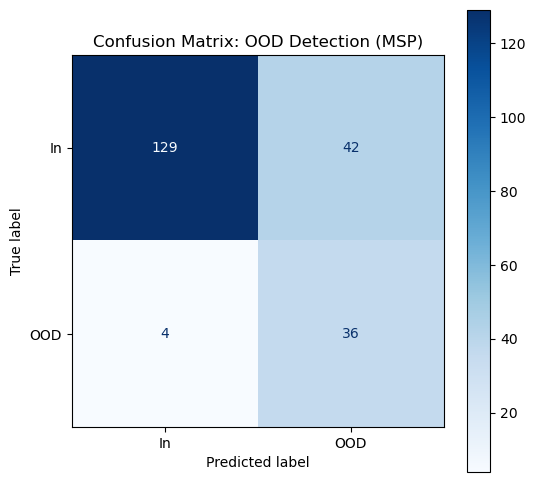

In [12]:
# Display confusion matrix for OOD detection using maximum softmax probabilities
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# True labels: 0 for in-distribution, 1 for OOD (CHAOS)
true_labels = np.concatenate([
    np.zeros(len(id_scores)),  # in-distribution
    np.ones(len(id_scores_chaos))  # OOD
])

# Predicted: 0 if below threshold (in), 1 if above (OOD)
pred_labels = np.concatenate([
    np.array(id_scores) < threshold,
    np.array(id_scores_chaos) < threshold
]).astype(int)

cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["In", "OOD"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues")
plt.title("Confusion Matrix: OOD Detection (MSP)")
plt.show()

In [13]:
# Threshold-free metrics on current (min-aggregated) scores
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

# Build labels and OOD scores (higher means more OOD)
y_true = np.concatenate([
    np.ones(len(id_scores_chaos), dtype=int),  # OOD
    np.zeros(len(val_id_scores), dtype=int)    # ID
])
scores_min = np.concatenate([
    1 - np.array(id_scores_chaos),  # invert MSP so higher => OOD
    1 - np.array(val_id_scores)
])

# AUROC and AUPR (OOD positive)
auroc_min = roc_auc_score(y_true, scores_min)
aupr_out_min = average_precision_score(y_true, scores_min)

# AUPR-In (ID positive)
y_true_in = 1 - y_true
scores_in = -scores_min  # higher means ID
aupr_in_min = average_precision_score(y_true_in, scores_in)

# FPR@95%TPR with ID as positive class
fpr_id, tpr_id, thr_id = roc_curve(y_true_in, scores_in)
target = 0.95
idx = np.where(tpr_id >= target)[0]
fpr_at_tpr95_min = fpr_id[idx[0]] if len(idx) else np.nan

# Detection Error and EER with ID positive
det_err_min = np.min(0.5 * ((1 - tpr_id) + fpr_id))
eer_idx = np.argmin(np.abs(fpr_id - (1 - tpr_id)))
eer_min = 0.5 * (fpr_id[eer_idx] + (1 - tpr_id)[eer_idx])

print({
    'AUROC_min': auroc_min,
    'AUPR_Out_min': aupr_out_min,
    'AUPR_In_min': aupr_in_min,
    'FPR@95%TPR_min': fpr_at_tpr95_min,
    'DetectionError_min': det_err_min,
    'EER_min': eer_min,
})

{'AUROC_min': 0.9782442748091602, 'AUPR_Out_min': 0.9163982594495265, 'AUPR_In_min': 0.9936883022741392, 'FPR@95%TPR_min': np.float64(0.1), 'DetectionError_min': np.float64(0.055534351145038165), 'EER_min': np.float64(0.055534351145038165)}


In [14]:
# Robust aggregations for volume-level MSP
from tqdm import tqdm

def compute_volume_scores(model, loader, agg: str = 'p05'):
    """Return MSP-based volume scores under different aggregations.
    agg in {'min','p01','p05','p10','mean','topk_mean_5'}
    """
    model.eval()
    out_scores = []
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Computing scores ({agg})"):
            image = batch["image"].to(device)
            output = sliding_window_inference(image, (96, 96, 96), 4, model, overlap=0.5)
            p = torch.sigmoid(output).detach().cpu().numpy().ravel()
            mcs = np.maximum(p, 1 - p)
            if agg == 'min':
                s = float(np.min(mcs))
            elif agg == 'p01':
                s = float(np.quantile(mcs, 0.01))
            elif agg == 'p05':
                s = float(np.quantile(mcs, 0.05))
            elif agg == 'p10':
                s = float(np.quantile(mcs, 0.10))
            elif agg == 'mean':
                s = float(np.mean(mcs))
            elif agg == 'topk_mean_5':
                k = max(1, int(0.05 * mcs.size))
                # mean of k lowest confidences
                s = float(np.mean(np.partition(mcs, k)[:k]))
            else:
                raise ValueError(f"Unknown agg: {agg}")
            out_scores.append(s)
    return np.array(out_scores)

# Example: evaluate with 5th-percentile aggregator
val_scores_p05 = compute_volume_scores(model, val_id_loader, 'p05')
chaos_scores_p05 = compute_volume_scores(model, chaos_loader, 'p05')

y_true = np.concatenate([
    np.ones(len(chaos_scores_p05), dtype=int),
    np.zeros(len(val_scores_p05), dtype=int)
])
scores_p05 = np.concatenate([
    1 - chaos_scores_p05,  # higher => OOD
    1 - val_scores_p05
])
auroc_p05 = roc_auc_score(y_true, scores_p05)
fpr_id, tpr_id, thr_id = roc_curve(1 - y_true, -scores_p05)  # ID positive
idx = np.where(tpr_id >= 0.95)[0]
fpr_at_tpr95_p05 = fpr_id[idx[0]] if len(idx) else np.nan
print({'AUROC_p05': auroc_p05, 'FPR@95%TPR_p05': fpr_at_tpr95_p05})

Computing scores (p05):   0%|          | 0/131 [00:00<?, ?it/s]Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /build/python-pytorch/src/pytorch-cuda/torch/csrc/autograd/python_variable_indexing.cpp:345.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /build/python-pytorch/src/pytorch-cuda/torch/csrc/autograd/python_variable_indexing.cpp:345.)
Computing scores (p05): 100%|██████████| 40/40 [01:14<00:00,  1.85s/it]

{'AUROC_p05': 0.9992366412213741, 'FPR@95%TPR_p05': np.float64(0.0)}


In [15]:
# Choosing a threshold on validation ID to control ID recall (TPR)
# For MSP-based aggregations where higher is more ID (mcs),
# a 5th percentile threshold on validation ID gives ~95% ID TPR by design.

target_tpr_id = 0.95
# Using p05 aggregation as example: threshold = 5th percentile of validation MSP
tau_val_p05 = np.quantile(val_scores_p05, 1 - target_tpr_id)
print({'tau_val_p05': float(tau_val_p05)})

# Evaluate on held-out test mix using this fixed threshold
pred_ood = np.concatenate([
    chaos_scores_p05 < tau_val_p05,  # OOD if MSP below threshold
    val_scores_p05 < tau_val_p05
]).astype(int)
labels = np.concatenate([
    np.ones_like(chaos_scores_p05, dtype=int),
    np.zeros_like(val_scores_p05, dtype=int)
])

from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
print({'accuracy': float(accuracy_score(labels, pred_ood)),
       'balanced_accuracy': float(balanced_accuracy_score(labels, pred_ood)),
       'confusion_matrix': confusion_matrix(labels, pred_ood)})

{'tau_val_p05': 0.9999962151050568}
{'accuracy': 0.9590643274853801, 'balanced_accuracy': 0.9732824427480916, 'confusion_matrix': array([[124,   7],
       [  0,  40]])}
